## Robustness Results (mCE and Relative mCE)

This notebook consolidates robustness metrics from saved CE JSONL files and generates:

- CE tables by corruption and model (15 **common** corruptions only; same set used for mCE)
- Summary tables with Clean Accuracy, mCE, and Relative mCE (mCE / Relative mCE averaged over those 15)
- Architecture Corruption Robustness plots for each dataset (saved under `figures/`)

Inputs (under `results/`):

- `cifar100c_baseline-MCUNet_Official_ce_results.jsonl`
- `cifar10c_baseline-MCUNet_ce_results.jsonl`
- `wakevision_baseline-MCUNet_ce_results.jsonl`

In [1]:
from pathlib import Path


def project_root() -> Path:
    """Resolve repo root (repo root, notebooks/, or other subfolders)."""
    cwd = Path.cwd().resolve()
    for d in [cwd, *cwd.parents]:
        km = d / "keras_models"
        if km.is_dir() and any(km.glob("*.keras")):
            return d
        if (d / ".git").exists() and (d / "results").is_dir():
            return d
    if (cwd / "datasets").is_dir() or (cwd / "results").is_dir():
        return cwd
    if (cwd.parent / "datasets").is_dir() or (cwd.parent / "results").is_dir():
        return cwd.parent
    return cwd


ROOT = project_root()


In [2]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = ROOT / "results"

DATASETS = {
    "cifar10c": {
        "label": "CIFAR-10-C",
        "jsonl": RESULTS_DIR / "cifar10c_baseline-MCUNet_ce_results.jsonl",
        "baseline": "MCUNet_Official",
        "clean_acc": RESULTS_DIR / "cifar10_clean_accuracy.json",
        # Old result files may still use MCUNet as model key.
        "aliases": {"MCUNet": "MCUNet_Official"},
        "plot_pdf": ROOT / "figures" / "cifar10c_architecture_corruption_robustness.pdf",
    },
    "cifar100c": {
        "label": "CIFAR-100-C",
        "jsonl": RESULTS_DIR / "cifar100c_baseline-MCUNet_Official_ce_results.jsonl",
        "baseline": "MCUNet_Official",
        "clean_acc": RESULTS_DIR / "cifar100_clean_accuracy.json",
        "aliases": {},
        "plot_pdf": ROOT / "figures" / "cifar100c_architecture_corruption_robustness.pdf",
    },
    "wakevision": {
        "label": "Wake Vision",
        "jsonl": RESULTS_DIR / "wakevision_baseline-MCUNet_ce_results.jsonl",
        "baseline": "MCUNet",
        "clean_acc": None,
        "aliases": {},
        # From the clean-eval output in wake_vision_robustness.ipynb.
        "clean_acc_fallback": {
            "MobileNetV3Small": 0.8613,
            "EfficientNetB0": 0.8773,
            "MCUNet": 0.8127,
        },
        "plot_pdf": ROOT / "figures" / "wakevision_architecture_corruption_robustness.pdf",
    },
}

In [3]:
def _load_json(path: Path, default=None):
    if default is None:
        default = {}
    if path is None or (not Path(path).exists()):
        return default
    return json.loads(Path(path).read_text(encoding="utf-8"))


def _load_latest_jsonl(path: Path, aliases: dict[str, str] | None = None) -> list[dict]:
    if aliases is None:
        aliases = {}
    latest = {}
    for line in Path(path).read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        row = json.loads(line)
        model = aliases.get(row.get("model"), row.get("model"))
        corr = row.get("corruption")
        if model is None or corr is None:
            continue
        row = dict(row)
        row["model"] = model
        latest[(model, corr)] = row
    return list(latest.values())


def _err(acc: float) -> float:
    return 1.0 - float(acc)


# Hendrycks & Dietterich (CIFAR-10-C / CIFAR-100-C): 15 common corruptions for mCE.
# Holdouts (excluded from mCE): speckle_noise, gaussian_blur, spatter, saturate.
COMMON_CORRUPTIONS_15 = frozenset(
    [
        "gaussian_noise",
        "shot_noise",
        "impulse_noise",
        "defocus_blur",
        "glass_blur",
        "motion_blur",
        "zoom_blur",
        "snow",
        "frost",
        "fog",
        "brightness",
        "contrast",
        "elastic_transform",
        "pixelate",
        "jpeg_compression",
    ]
)


def _compute_mce(rows: list[dict]) -> pd.Series:
    df = pd.DataFrame(rows)
    df = df[df["corruption"].isin(COMMON_CORRUPTIONS_15)]
    return df.groupby("model")["ce_mean_1_5"].mean().sort_values() * 100.0


def _compute_relative_mce(rows: list[dict], clean_acc: dict[str, float], baseline_name: str) -> pd.Series:
    if not clean_acc or baseline_name not in clean_acc:
        return pd.Series(dtype=float)

    df = pd.DataFrame(rows)
    rel_by_model = {}

    for model, g_model in df.groupby("model"):
        if model not in clean_acc:
            continue

        model_clean_err = _err(clean_acc[model])
        baseline_clean_err = _err(clean_acc[baseline_name])

        rel_ce_vals = []
        for corr in sorted(g_model["corruption"].unique()):
            if corr not in COMMON_CORRUPTIONS_15:
                continue
            row_model = g_model[g_model["corruption"] == corr]
            row_base = df[(df["model"] == baseline_name) & (df["corruption"] == corr)]
            if row_model.empty or row_base.empty:
                continue

            rm = row_model.iloc[-1]
            rb = row_base.iloc[-1]

            num_rel = 0.0
            den_rel = 0.0
            ok = True
            for s in [1, 2, 3, 4, 5]:
                am = rm.get(f"acc_s{s}")
                ab = rb.get(f"acc_s{s}")
                if am is None or ab is None:
                    ok = False
                    break
                num_rel += (_err(am) - model_clean_err)
                den_rel += (_err(ab) - baseline_clean_err)

            if ok and den_rel > 0:
                rel_ce_vals.append(num_rel / den_rel)

        if rel_ce_vals:
            rel_by_model[model] = float(np.mean(rel_ce_vals) * 100.0)

    return pd.Series(rel_by_model).sort_values()


def _ce_pivot(rows: list[dict]) -> pd.DataFrame:
    df = pd.DataFrame(rows)
    df = df[df["corruption"].isin(COMMON_CORRUPTIONS_15)]
    piv = (
        df.pivot_table(index="corruption", columns="model", values="ce_mean_1_5", aggfunc="mean")
        .sort_index()
        .sort_index(axis=1)
    )
    return piv * 100.0


def _plot_architecture_robustness(dataset_label: str, summary_df: pd.DataFrame, out_pdf: Path):
    required = {"clean_acc_pct", "mCE_pct", "relative_mCE_pct"}
    if not required.issubset(summary_df.columns):
        print(f"Skipping plot for {dataset_label}: missing columns {required - set(summary_df.columns)}")
        return

    plot_df = summary_df.dropna(subset=["clean_acc_pct", "mCE_pct", "relative_mCE_pct"]).copy()
    if plot_df.empty:
        print(f"Skipping plot for {dataset_label}: no rows with complete metrics")
        return

    x = plot_df["clean_acc_pct"].values
    y_mce = plot_df["mCE_pct"].values
    y_rel = plot_df["relative_mCE_pct"].values
    labels = plot_df.index.tolist()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x, y_rel, "o--", color="#ff7f0e", label="Relative mCE", markersize=6)
    ax.plot(x, y_mce, "o--", color="#1f77b4", label="mCE", markersize=6)

    for i, name in enumerate(labels):
        ax.annotate(name, (x[i], y_mce[i]), textcoords="offset points", xytext=(8, -10), fontsize=9)
        ax.annotate(name, (x[i], y_rel[i]), textcoords="offset points", xytext=(8, 8), fontsize=9)

    ax.set_xlabel("Architecture Accuracy (%)")
    ax.set_ylabel("%")
    ax.set_title(f"{dataset_label}: Architecture Corruption Robustness")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend()

    y_max = max(float(np.nanmax(y_mce)), float(np.nanmax(y_rel))) * 1.15
    ax.set_ylim(0, max(120.0, y_max))

    plt.tight_layout()
    plt.savefig(out_pdf, format="pdf", bbox_inches="tight")
    print(f"Saved plot: {out_pdf}")
    plt.show()


Dataset: CIFAR-10-C

CE (%) by corruption and model (15 common corruptions; mCE uses the same set)


model,EfficientNetB0,MCUNet_Official,MobileNetV3Small
corruption,,,
brightness,39.21,202.50,66.66
contrast,49.98,91.26,68.08
defocus_blur,38.35,113.80,55.52
elastic_transform,63.69,134.70,77.33
fog,61.17,131.03,101.62
frost,47.89,165.10,64.17
gaussian_noise,69.10,129.85,93.65
glass_blur,88.68,108.13,79.66
impulse_noise,59.20,128.47,116.26



Summary table


,clean_acc_pct,mCE_pct,relative_mCE_pct
MCUNet_Official,78.88,135.92,100.00
EfficientNetB0,94.61,57.59,64.12
MobileNetV3Small,90.44,78.45,74.86


Saved plot: C:/anonymous/anonymous/anonymous/Lightweight Analyses/anonymous/Lightweight Analyses\anonymous\Lightweight Analyses\anonymous\cifar10c_architecture_corruption_robustness.pdf


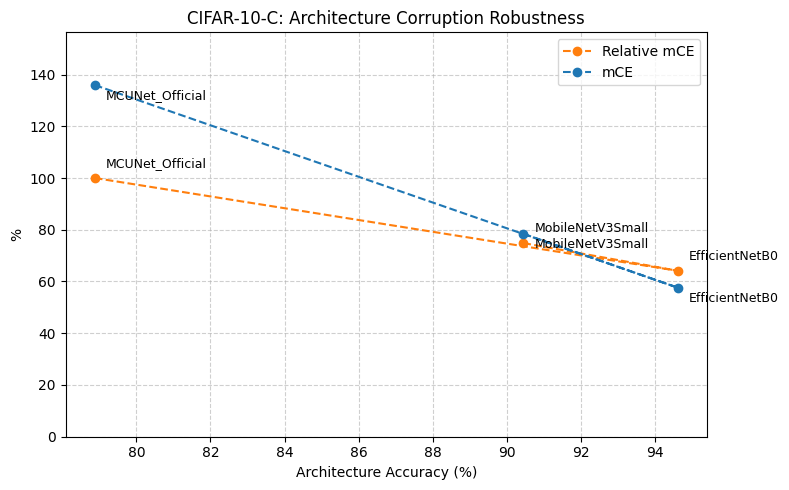


Dataset: CIFAR-100-C

CE (%) by corruption and model (15 common corruptions; mCE uses the same set)


model,EfficientNetB0,MCUNet,MCUNet_512KB_2MB,MCUNet_Official,MobileNetV3Small
corruption,,,,,
brightness,44.20,101.50,76.57,100.0,55.13
contrast,72.60,129.24,104.49,100.0,81.31
defocus_blur,60.24,116.21,96.25,100.0,69.23
elastic_transform,69.92,106.90,90.56,100.0,75.75
fog,69.08,125.81,95.16,100.0,85.24
frost,54.97,93.06,81.22,100.0,59.10
gaussian_noise,76.50,94.48,98.08,100.0,86.51
glass_blur,98.89,86.38,92.23,100.0,89.46
impulse_noise,68.89,99.85,92.44,100.0,100.71



Summary table


,clean_acc_pct,mCE_pct,relative_mCE_pct
MCUNet_Official,58.68,100.00,100.00
EfficientNetB0,78.32,67.35,96.33
MobileNetV3Small,73.01,76.26,96.40
MCUNet_512KB_2MB,NaN,91.77,NaN
MCUNet,NaN,103.69,NaN


Saved plot: C:/anonymous/anonymous/anonymous/Lightweight Analyses/anonymous/Lightweight Analyses\anonymous\Lightweight Analyses\anonymous\cifar100c_architecture_corruption_robustness.pdf


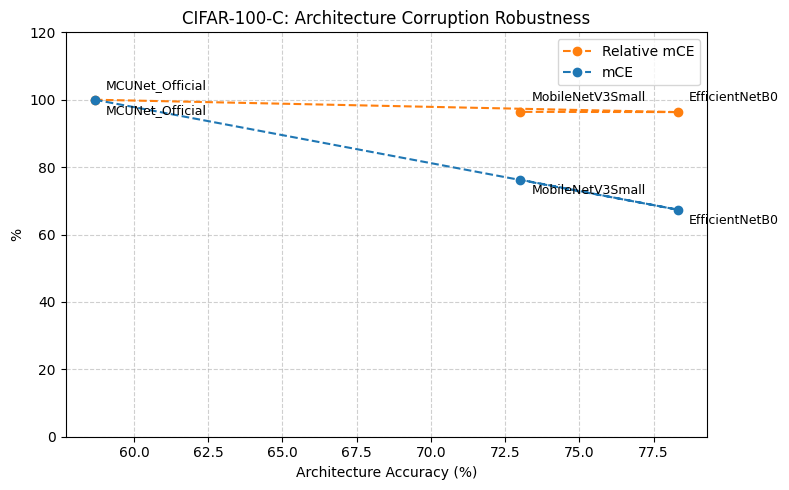


Dataset: Wake Vision

CE (%) by corruption and model (15 common corruptions; mCE uses the same set)


model,EfficientNetB0,MCUNet,MobileNetV3Small
corruption,,,
brightness,54.77,100.0,69.41
contrast,69.91,100.0,99.85
defocus_blur,71.78,100.0,66.29
elastic_transform,67.36,100.0,70.66
fog,58.60,100.0,90.40
frost,58.31,100.0,68.31
gaussian_noise,47.74,100.0,67.98
glass_blur,51.30,100.0,61.84
impulse_noise,47.25,100.0,70.17



Summary table


,clean_acc_pct,mCE_pct,relative_mCE_pct
MCUNet,81.27,100.00,100.00
EfficientNetB0,87.73,58.72,63.11
MobileNetV3Small,86.13,71.91,35.01


Saved plot: C:/anonymous/anonymous/anonymous/Lightweight Analyses/anonymous/Lightweight Analyses\anonymous\Lightweight Analyses\anonymous\wakevision_architecture_corruption_robustness.pdf


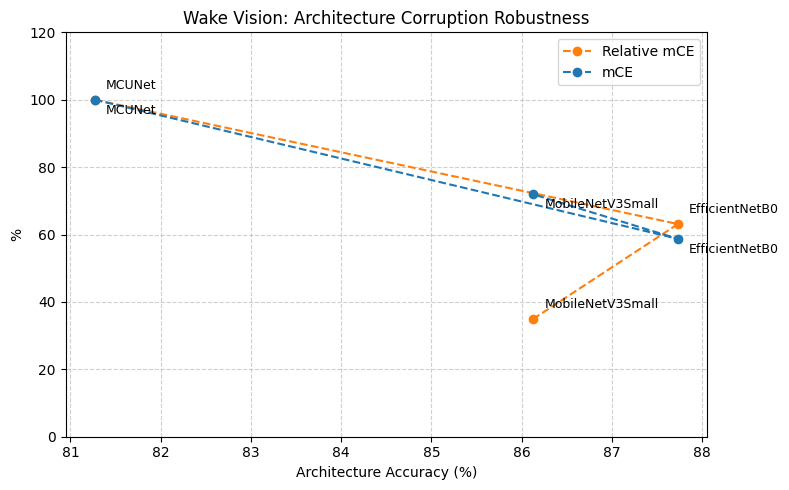

In [4]:
all_summaries = {}
all_ce_tables = {}

for key, cfg in DATASETS.items():
    print("\n" + "=" * 88)
    print(f"Dataset: {cfg['label']}")
    print("=" * 88)

    jsonl_path = cfg["jsonl"]
    if not jsonl_path.exists():
        print(f"Missing file: {jsonl_path}")
        continue

    rows = _load_latest_jsonl(jsonl_path, aliases=cfg.get("aliases", {}))
    if not rows:
        print(f"No rows loaded from: {jsonl_path}")
        continue

    baseline_name = cfg["baseline"]

    clean_acc = {}
    clean_acc_path = cfg.get("clean_acc")
    if clean_acc_path is not None and Path(clean_acc_path).exists():
        clean_acc = _load_json(Path(clean_acc_path), default={})
    elif cfg.get("clean_acc_fallback"):
        clean_acc = dict(cfg["clean_acc_fallback"])

    # Apply model aliases to clean-accuracy keys too.
    aliases = cfg.get("aliases", {})
    if aliases:
        clean_acc = {aliases.get(k, k): v for k, v in clean_acc.items()}

    ce_table = _ce_pivot(rows)
    all_ce_tables[key] = ce_table
    print("\nCE (%) by corruption and model (15 common corruptions; mCE uses the same set)")
    display(ce_table.round(2))

    mce_pct = _compute_mce(rows)
    rel_mce_pct = _compute_relative_mce(rows, clean_acc=clean_acc, baseline_name=baseline_name)

    summary = pd.DataFrame(index=sorted(set(mce_pct.index) | set(rel_mce_pct.index) | set(clean_acc.keys())))
    summary["clean_acc_pct"] = pd.Series({k: v * 100.0 for k, v in clean_acc.items()})
    summary["mCE_pct"] = mce_pct
    summary["relative_mCE_pct"] = rel_mce_pct

    # Keep baseline first in display, then sort by mCE.
    ordered_idx = [baseline_name] + [i for i in summary.sort_values("mCE_pct").index if i != baseline_name]
    summary = summary.reindex([i for i in ordered_idx if i in summary.index])

    all_summaries[key] = summary
    print("\nSummary table")
    display(summary.round(2))

    if summary["relative_mCE_pct"].isna().all():
        print("Relative mCE could not be computed (missing clean accuracy and/or baseline mapping).")

    _plot_architecture_robustness(
        dataset_label=cfg["label"],
        summary_df=summary,
        out_pdf=cfg["plot_pdf"],
    )